In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
N = 300

def rhs(t, F, params):
    """
    Right-hand side for the system F0..F8.
    F is ordered [F0, F1, F2, F3, F4, F5, F6, F7, F8].
    params is a dict containing: k_avg, lam1, lam2, mu, mu_bar
    """
    k = params['k_avg']
    lam1 = params['lam1']
    lam2 = params['lam2']
    mu = params['mu']
    mu_bar = params['mu_bar']
    
    F0, F1, F2, F3, F4, F5, F6, F7, F8 = F

    # common combinations
    comb1 = F1 + F4 + F7
    comb2 = F3 + F4 + F5

    dF0 = -k * lam1 * F0 * comb1 - k * lam2 * F0 * comb2
    dF1 = -F1 * mu - k * lam2 * F1 * comb2 + k * lam1 * F0 * comb1
    dF2 = F1 * mu - k * F2 * lam2 * comb2
    dF3 = -k * lam1 * F3 * comb1 - F3 * mu + k * lam2 * F0 * comb2
    dF4 = k * lam1 * F3 * comb1 + k * lam2 * F1 * comb2 - F4 * mu_bar
    dF5 = k * lam2 * F2 * comb2 - F5 * mu
    dF6 = -k * lam1 * F6 * comb1 + F3 * mu
    dF7 = k * lam1 * F6 * comb1 - F7 * mu
    dF8 = F4 * mu_bar + F7 * mu + F5 * mu

    return [dF0, dF1, dF2, dF3, dF4, dF5, dF6, dF7, dF8]

#Initial conditions
# Order: F0, F1, F2, F3, F4, F5, F6, F7, F8
y0 = [(N-2)/N, 1/N, 0, 1/N, 0, 0, 0, 0, 0]  

# --- Time span and evaluation times ---
t_span = (0.0, 35.0)               # start and end time
t_eval = np.linspace(t_span[0], t_span[1], 501)


In [3]:
L = 0.25

In [4]:
mu_bar_range = [0.2, 0.4, .6, 1]

In [5]:
c_mu = []

In [6]:
t = t_eval

In [7]:
for m in mu_bar_range:
    params = {
    'k_avg': 10,    # <k>
    'lam1': L,     # lambda_1
    'lam2': L,     # lambda_2
    'mu': 1.0,       # mu
    'mu_bar': m    # \bar{\mu}
    }

    sol = solve_ivp(lambda t, y: rhs(t, y, params),
                t_span, y0, t_eval=t_eval, method='RK45', atol=1e-8, rtol=1e-6)

    # Check success
    if not sol.success:
        raise RuntimeError("ODE solver failed: " + sol.message)

    c = sol.y[4] 
    
    c_mu.append(c)

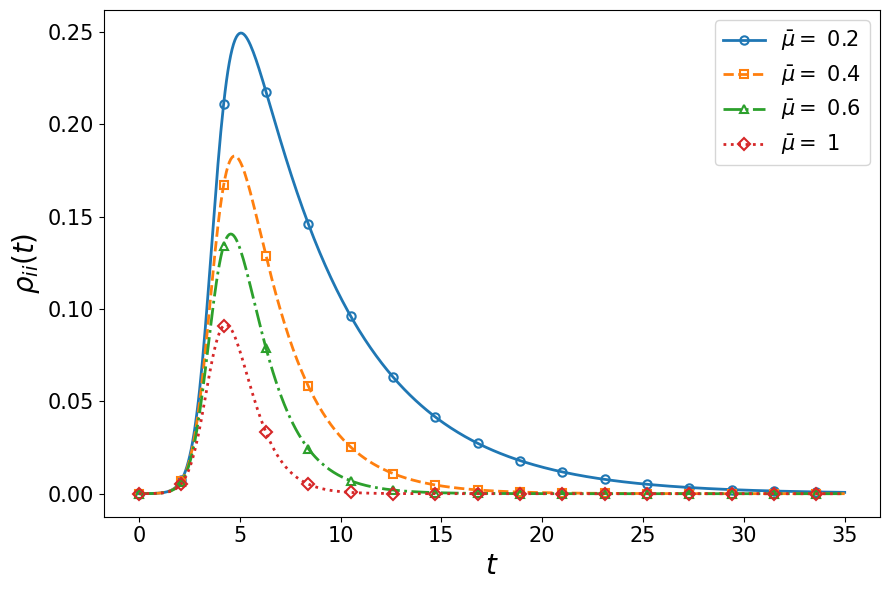

In [9]:
plt.figure(figsize=(9,6))

markers = ['o', 's', '^', 'D']   
linestyles = ['-', '--', '-.', ':']


for mu in range(len(mu_bar_range)):
    plt.plot(
        t, c_mu[mu],
        label=rf'$\bar{{\mu}} =$ {mu_bar_range[mu]}',
        marker=markers[mu],
        markevery=30,            
        markersize=6,
        linewidth=2,
        markerfacecolor='none',  
        markeredgewidth=1.5,
        linestyle=linestyles[mu]
    )

plt.xlabel(r"$t$", fontsize=20)
plt.ylabel(r"${\rho_{ii}}(t)$", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(loc='best', fontsize=15)
plt.tight_layout()
plt.show()


## Burden

In [10]:
mu_bar_range = np.linspace(0.1, 1, 100)

In [11]:
B_vals = []

In [12]:
for m in mu_bar_range:
    params = {
    'k_avg': 10,    # <k>
    'lam1': L,     # lambda_1
    'lam2': L,     # lambda_2
    'mu': 1.0,       # mu
    'mu_bar': m    # \bar{\mu}
    }

    sol = solve_ivp(lambda t, y: rhs(t, y, params),
                t_span, y0, t_eval=t_eval, method='RK45', atol=1e-8, rtol=1e-6)

    # Check success
    if not sol.success:
        raise RuntimeError("ODE solver failed: " + sol.message)

    c = sol.y[4] 
    
    B_vals.append(np.trapezoid(c, sol.t))

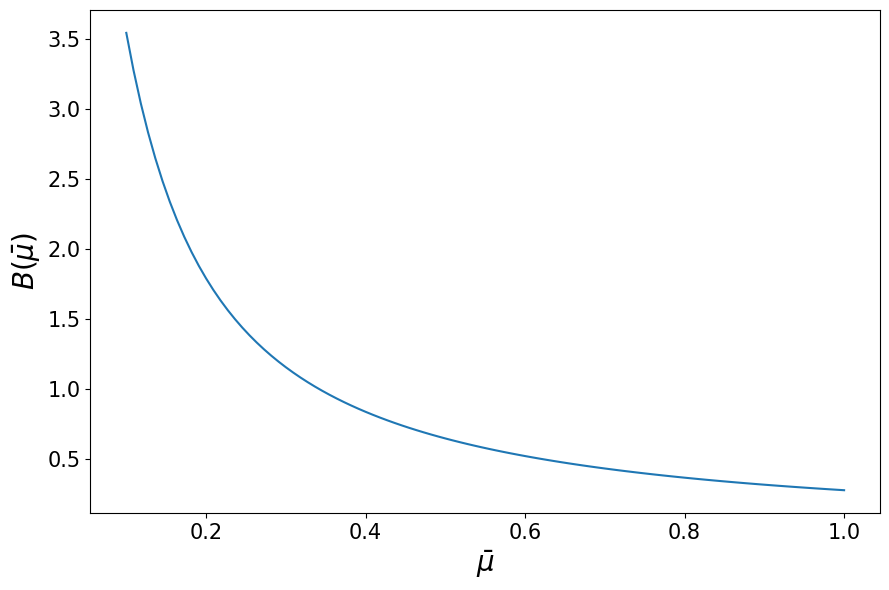

In [13]:
plt.figure(figsize=(9,6))
plt.plot(mu_bar_range, B_vals)
#plt.title("Cumulative co-infection burden", fontsize=15)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.xlabel(r"$\bar{\mu}$", fontsize=20)
plt.ylabel(r"$B(\bar{\mu}$)", fontsize=20)


plt.tight_layout()
plt.show()
